In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/home/rayan/Downloads/archive (1)/taxi_tripdata.csv')
df.head()

/tmp/ipykernel_10342/153125574.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('/home/rayan/Downloads/archive (1)/taxi_tripdata.csv')


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,1.0,2021-07-01 00:30:52,2021-07-01 00:35:36,N,1.0,74,168,1.0,1.20,6.0,0.5,0.5,0.00,0.0,NaN,0.3,7.30,2.0,1.0,0.0
1,2.0,2021-07-01 00:25:36,2021-07-01 01:01:31,N,1.0,116,265,2.0,13.69,42.0,0.5,0.5,0.00,0.0,NaN,0.3,43.30,2.0,1.0,0.0
2,2.0,2021-07-01 00:05:58,2021-07-01 00:12:00,N,1.0,97,33,1.0,0.95,6.5,0.5,0.5,2.34,0.0,NaN,0.3,10.14,1.0,1.0,0.0
3,2.0,2021-07-01 00:41:40,2021-07-01 00:47:23,N,1.0,74,42,1.0,1.24,6.5,0.5,0.5,0.00,0.0,NaN,0.3,7.80,2.0,1.0,0.0
4,2.0,2021-07-01 00:51:32,2021-07-01 00:58:46,N,1.0,42,244,1.0,1.10,7.0,0.5,0.5,0.00,0.0,NaN,0.3,8.30,2.0,1.0,0.0


In [3]:
df.shape

(83691, 20)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83691 entries, 0 to 83690
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               51173 non-null  float64
 1   lpep_pickup_datetime   83691 non-null  object 
 2   lpep_dropoff_datetime  83691 non-null  object 
 3   store_and_fwd_flag     51173 non-null  object 
 4   RatecodeID             51173 non-null  float64
 5   PULocationID           83691 non-null  int64  
 6   DOLocationID           83691 non-null  int64  
 7   passenger_count        51173 non-null  float64
 8   trip_distance          83691 non-null  float64
 9   fare_amount            83691 non-null  float64
 10  extra                  83691 non-null  float64
 11  mta_tax                83691 non-null  float64
 12  tip_amount             83691 non-null  float64
 13  tolls_amount           83691 non-null  float64
 14  ehail_fee              0 non-null      float64
 15  im

In [5]:
df['lpep_dropoff_datetime']=pd.to_datetime(df['lpep_dropoff_datetime'])
df['lpep_pickup_datetime']=pd.to_datetime(df['lpep_pickup_datetime'])

In [6]:
df["pickup_hour"] = df["lpep_pickup_datetime"].dt.hour
df["pickup_day"] = df["lpep_pickup_datetime"].dt.day
df["pickup_month"] = df["lpep_pickup_datetime"].dt.month
df["pickup_weekday"] = df["lpep_pickup_datetime"].dt.weekday  

# Trip duration (in minutes)
df["trip_duration"] = (
    (df["lpep_dropoff_datetime"] - df["lpep_pickup_datetime"])
    .dt.total_seconds() / 60
)

# Speed (km/min or mile/min depending on dataset)
df["speed"] = df["trip_distance"] / df["trip_duration"]

# Weekend feature
df["is_weekend"] = df["pickup_weekday"].isin([5, 6]).astype(int)

df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,payment_type,trip_type,congestion_surcharge,pickup_hour,pickup_day,pickup_month,pickup_weekday,trip_duration,speed,is_weekend
0,1.0,2021-07-01 00:30:52,2021-07-01 00:35:36,N,1.0,74,168,1.0,1.20,6.0,...,2.0,1.0,0.0,0,1,7,3,4.733333,0.253521,0
1,2.0,2021-07-01 00:25:36,2021-07-01 01:01:31,N,1.0,116,265,2.0,13.69,42.0,...,2.0,1.0,0.0,0,1,7,3,35.916667,0.381160,0
2,2.0,2021-07-01 00:05:58,2021-07-01 00:12:00,N,1.0,97,33,1.0,0.95,6.5,...,1.0,1.0,0.0,0,1,7,3,6.033333,0.157459,0
3,2.0,2021-07-01 00:41:40,2021-07-01 00:47:23,N,1.0,74,42,1.0,1.24,6.5,...,2.0,1.0,0.0,0,1,7,3,5.716667,0.216910,0
4,2.0,2021-07-01 00:51:32,2021-07-01 00:58:46,N,1.0,42,244,1.0,1.10,7.0,...,2.0,1.0,0.0,0,1,7,3,7.233333,0.152074,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

VendorID                 32518
lpep_pickup_datetime         0
lpep_dropoff_datetime        0
store_and_fwd_flag       32518
RatecodeID               32518
PULocationID                 0
DOLocationID                 0
passenger_count          32518
trip_distance                0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
ehail_fee                83691
improvement_surcharge        0
total_amount                 0
payment_type             32518
trip_type                32518
congestion_surcharge     32518
pickup_hour                  0
pickup_day                   0
pickup_month                 0
pickup_weekday               0
trip_duration                0
speed                       73
is_weekend                   0
dtype: int64

In [9]:
df = df.drop(columns=["ehail_fee"])


In [10]:
# passenger_count → fill with median
df["passenger_count"] = df["passenger_count"].fillna(df["passenger_count"].median())

# congestion_surcharge → usually 0
df["congestion_surcharge"] = df["congestion_surcharge"].fillna(0)


In [11]:
# Fill with most frequent (mode)
categorical_cols = [
    "payment_type",
    "trip_type",
    "RatecodeID",
    "VendorID",
    "store_and_fwd_flag"
]

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


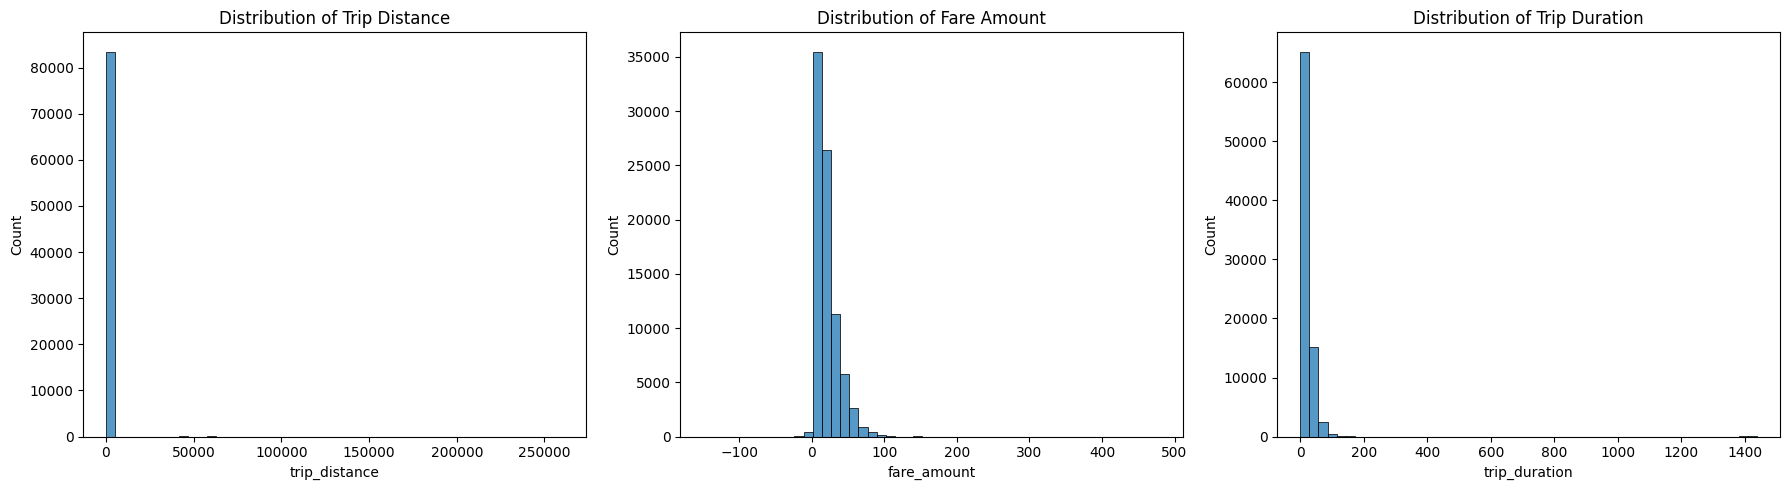

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Trip distance
sns.histplot(df['trip_distance'], bins=50, ax=axes[0])
axes[0].set_title('Distribution of Trip Distance')

# Fare amount
sns.histplot(df['fare_amount'], bins=50, ax=axes[1])
axes[1].set_title('Distribution of Fare Amount')

# Trip duration
sns.histplot(df['trip_duration'], bins=50, ax=axes[2])
axes[2].set_title('Distribution of Trip Duration')

plt.tight_layout()
plt.show()

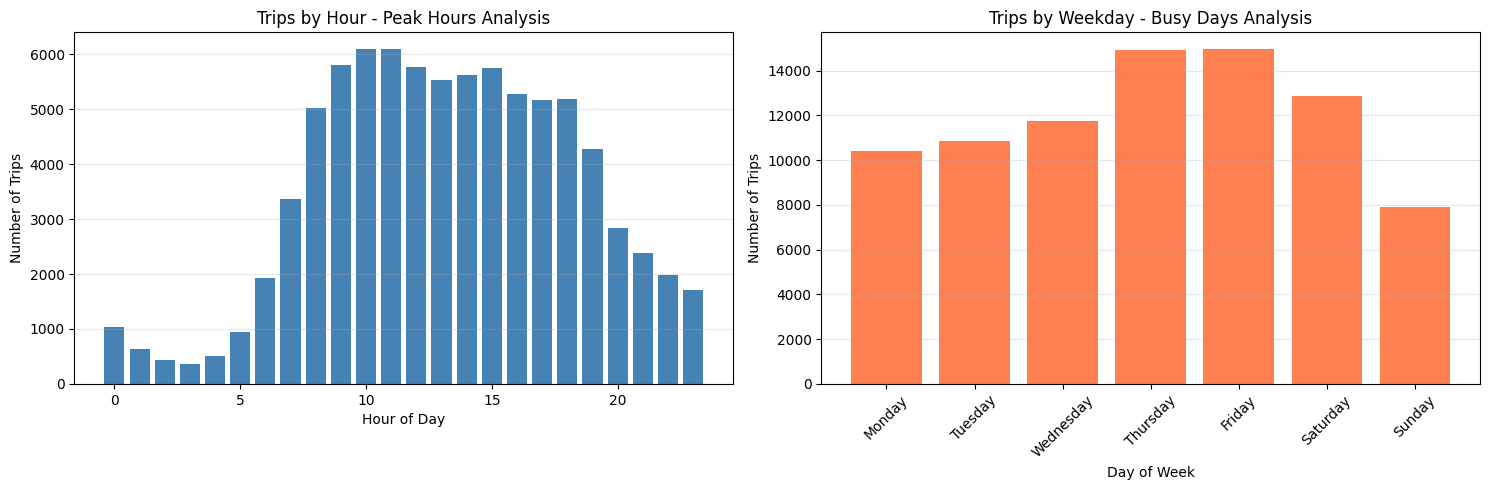

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Peak hours analysis
trips_by_hour = df['pickup_hour'].value_counts().sort_index()
axes[0].bar(trips_by_hour.index, trips_by_hour.values, color='steelblue')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Trips')
axes[0].set_title('Trips by Hour - Peak Hours Analysis')
axes[0].grid(axis='y', alpha=0.3)

# Busy days analysis
trips_by_weekday = df['pickup_weekday'].value_counts().sort_index()
weekday_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
axes[1].bar(range(7), [trips_by_weekday.get(i, 0) for i in range(7)], color='coral')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Number of Trips')
axes[1].set_title('Trips by Weekday - Busy Days Analysis')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(weekday_names, rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

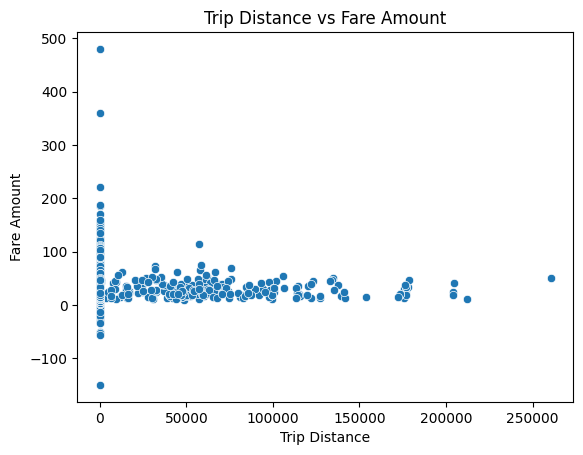

In [14]:
sns.scatterplot(data=df, x='trip_distance', y='fare_amount')
plt.title('Trip Distance vs Fare Amount')
plt.xlabel('Trip Distance')
plt.ylabel('Fare Amount')
plt.show()

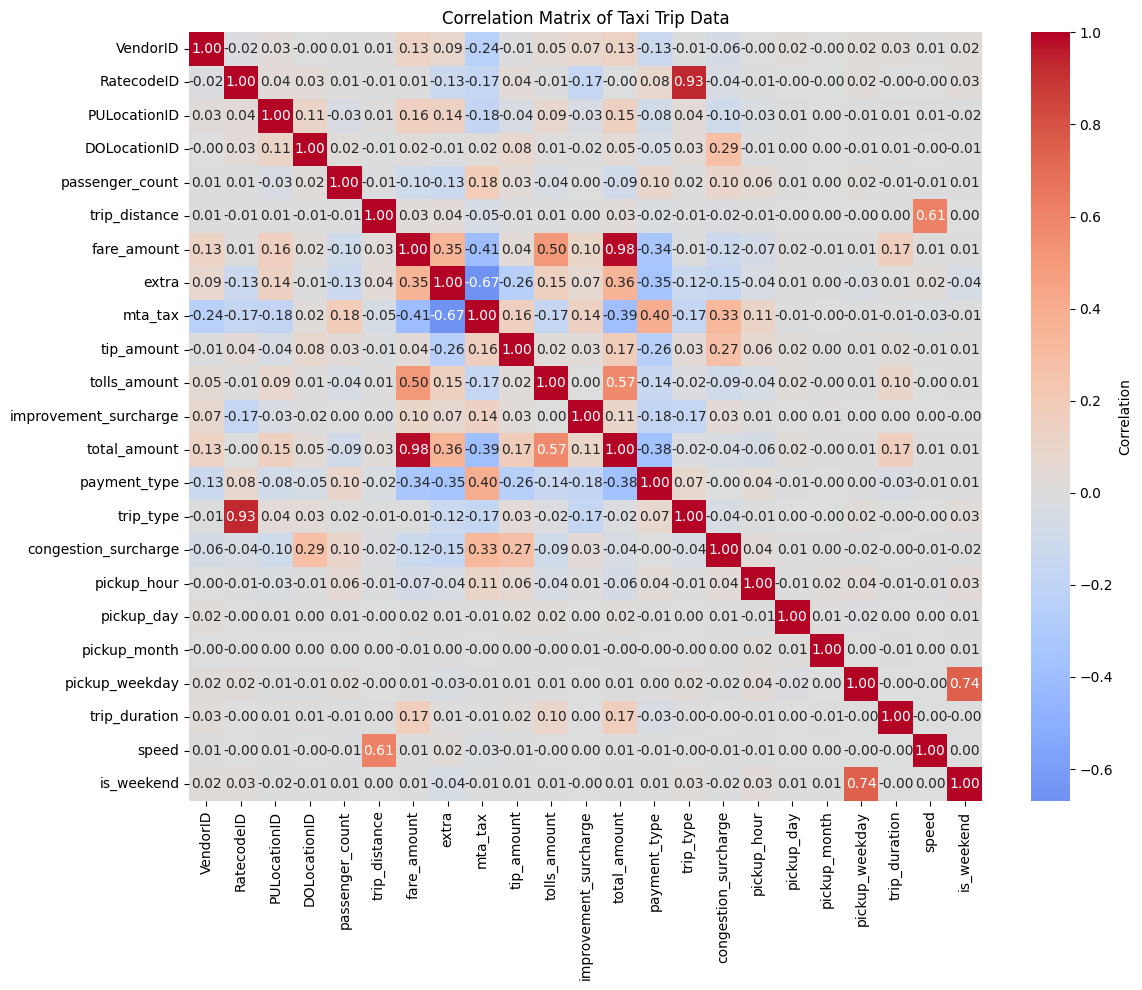

In [15]:
# Calculate correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Create a heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix of Taxi Trip Data')
plt.tight_layout()
plt.show()

In [18]:
df.to_csv('/home/rayan/Downloads/taxi_tripdata_cleaned.csv', index=False)